# Assignment 8: Unsupervised Clustering K-means

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Please submit your solution as a Jupyter notebook (.ipynb) and as a PDF created from the (executed) Jupyter notebook.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`) and similarly for the PDF.
- Submit the corresponding files to ILIAS


### Additional information for this assignment
- Remember to test to run your notebook top to bottom, as this is the way we will evaluate it!
- Some functions contain typing information (e.g. ``foo: list`` -> the variable ``foo`` is a ``list``). Please make sure your implementation uses the same types in function parameters and return values. For more information take a look at the at the [python typing documention](https://mypy.readthedocs.io/en/stable/).
- Some cells may be empty or only contain testing statements (see below) and are used for later evaluation. Do **not** modify or delete them.
- We provide some tests (most often ``assert`` statements) for you to check whether your implementation is correct. However, most tests are hidden, thus remember to **carefully** test the corner cases (e.g. different input parameters) of your implementation!

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements from the first assignment via ```python3 -m pip install -r requirements.txt```. *Do not use any additional python packages*.

Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. The following imports should not throw any errors:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

---
<span style="color:red">Please also inlcude your name and matriculation number here:

## Implement *K-Means++*
In this task, your goal is to implement some helpful functions and the entire process of K-Means++ algorithm to solve an unsupervised clustering problem.

#### <span style="color:red">[TODO]</span> Complete the distance function (1 pt)

In [2]:
def euclidean(point, data):
    """
    return Euclidean distance between the specified point and all data points.
    inputs:
        - point (np.array): shaped like (2,)
        - data (np.array): shaped like (n,2) or (list): a list of n elements with each of them np.array shaped like (2,)
    output:
        - dist (np.array): shaped like (n,)
    """
    ### BEGIN SOLUTION
    dist = np.sqrt(np.sum((point - data)**2, axis=1))
    return dist
    ### END SOLUTION

In [23]:
def print_assert(condition_value):
    print(condition_value)
    assert condition_value
# check (True means correct, False means incorrect)
print_assert(np.all(euclidean(np.array([0,0]), np.array([[0,0]])) == np.array([0])))
print_assert(np.all(euclidean(np.array([0,0]), np.array([[1,0]])) == np.array([1])))
print_assert(np.sum(euclidean(np.array([0,0]), np.array([[0,0], [1,0], [2,0]]))) == 3)

True
True
True


In [4]:
'''check for KMeans class (not visible to students)'''
### BEGIN HIDDEN TESTS
assert np.abs(euclidean(np.array([0,1]), np.array([[1,0]])) - 1.4142135624) < 1e-6 
assert np.abs(euclidean(np.array([0,2]), np.array([[1,0]])) - 2.2360679775) < 1e-6
assert np.sum(euclidean(np.array([0,0]), np.array([[0,0], [0,2], [0,1]]))) == 3
### END HIDDEN TESTS

#### <span style="color:red">[TODO]</span> Complete the centroid initialization (2 pts)

Based on the algorithm K-Means, K-Means++ specifies a proposal of centroid initialization to mitigate the sensitivity problem. To be more specific, the algorithm is as follows:

* Choose one centroid uniformly at random among all data points
* For each data point $x$, compute $D(x)$, which denotes the distance between x and **the nearest centroid** that has already been chosen
* Sample one new data point as the new centroid, using a weighted probability distribution where a point x is chosen with probability proportional to $D(x)^2$
* Repeat Step 2 and Step 3 until k centroids have been chosen

In [ ]:
def centroid_initialization(X_train, centroid_list, n_clusters, sample_mode="sample"):
    """
    return a list of initial centroids for the following k-means clustering
    inputs: 
        - X_train (np.array): shaped like (n,2), all data points used for fitting
        - centroid_list list: a list which already contains the first centroid
        - n_clusters (int): specifies how many clusters will be formed
    """
    
    for _ in range(n_clusters-1):
        # Calculate D(x), the distances from points to their nearest centroids
        # and normalize them to get probabilities based on squared distances, D(x)^2
        # use variable name `dists`

        ### BEGIN SOLUTION
        dists_cand = np.array([euclidean(centroid, X_train) for centroid in centroid_list])
        dists = np.min(dists_cand, axis=0)
        dists = dists**2
        dists /= np.sum(dists)
        ### END SOLUTION
        
        if sample_mode == "sample":
            # Choose remaining points based on their distances
            new_centroid_idx, = np.random.choice(range(len(X_train)), size=1, p=dists)
            centroid_list += [X_train[new_centroid_idx]]
        else:
            centroid_list += [X_train[np.argmax(dists)]]
    
    return centroid_list
    

In [24]:
# check
X_test = np.array([[1,0],[3,0],[0,3],[2,2],[3,4]])
centroids_test = centroid_initialization(X_test, [np.array([1,0])], 3, sample_mode=None)
print_assert(np.sum(centroids_test[1]) == 7)
print_assert(centroids_test[2][1] == 3)

True
True


In [8]:
'''check for KMeans class (not visible to students)'''
### BEGIN HIDDEN TESTS
X_test = np.array([[1,1],[1,4],[3,4],[4,4]])
centroids_test = centroid_initialization(X_test, [np.array([4,4])], 3, sample_mode=None)
assert np.sum(centroids_test[1]) == 2
assert centroids_test[2][0] == 1
### END HIDDEN TESTS

#### <span style="color:red">[TODO]</span> Complete k-means (5 pts)

In [9]:
class KMeans:
    def __init__(self, n_clusters=8, max_iter=300, random_seed=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_seed = random_seed
        
        np.random.seed(self.random_seed)
        random.seed(self.random_seed)
        
    def fit(self, X_train):
        """
        realize the k-means clustering
        inputs: 
            - X_train (np.array): shaped like (n,2), all data points used for fitting
        """
                
        # Initialize the centroids
        centroids = [random.choice(X_train)]
        self.centroids = centroid_initialization(X_train, centroids, self.n_clusters)

        # Iterate, adjusting centroids until converged or until passed max_iter
        iteration = 0
        prev_centroids = None
        while np.not_equal(self.centroids, prev_centroids).any() and iteration < self.max_iter:
            # Assign each point to the closest centroid
            sorted_points = [[] for _ in range(self.n_clusters)]
            for x in X_train:
                dists = euclidean(x, self.centroids)
                
                # Identify the index of the closest cluster for this data point as `centroid_idx`
                # Append x to the sublist which belongs to `centroid_idx`
                ### BEGIN SOLUTION
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)
                ### END SOLUTION
                
            # Push current centroids to previous
            prev_centroids = self.centroids

            # Reassign centroids as mean of the points belonging to them
            ### BEGIN SOLUTION
            new_centroids = [np.mean(cluster, axis=0) for cluster in sorted_points]
            ### END SOLUTION
            self.centroids = new_centroids
            # Catch any np.nans, resulting from a centroid having no points
            for i, centroid in enumerate(self.centroids):
                if np.isnan(centroid).any(): 
                    self.centroids[i] = prev_centroids[i]
            iteration += 1
    
    def evaluate(self, X):
        """
        evalute data X using the fitted k means
        return a list of centroids and a list of corresponding indices
        inputs: 
            - X (np.array): shaped like (n,2), all data points used for evaluation
        """
        centroids = []
        centroid_idxs = []
        for x in X:
            # assign each data point to its nearest centroid
            ### BEGIN SOLUTION
            dists = euclidean(x, self.centroids)
            centroid_idx = np.argmin(dists)
            ### END SOLUTION

            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)
        return centroids, centroid_idxs

## Evaluate *K-Means++*
In this section, you will be asked to do the clustering with several datasets and compare the results of K-Means++.

In [10]:
def visualization_clusters(X, kmeans, classification):
    """
    visualize clusters with the fitted k means
    inputs: 
        - X (np.array): shaped like (n,2), all data points
        - kmeans (class KMeans): it can provide the fitted k means
        - classification (list): a list of indices of different cluster means
    """
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    plt.plot(
        [x for x, _ in kmeans.centroids],
        [y for _, y in kmeans.centroids],
        'k+',
        markersize=10,
    )
    
    plt.scatter(x=[X[0] for X in X], y=[X[1] for X in X], c=[colors[i] for i in classification])
    plt.gca().set_aspect(1)
    plt.show()

In [11]:
# get a dataset of 2D points
X_train = np.load('data/clustering_data1.npy')

# Fit centroids to dataset
kmeans = KMeans(n_clusters=3, max_iter=500, random_seed=110)
kmeans.fit(X_train)
class_centers, classification = kmeans.evaluate(X_train)

In [ ]:
# check
print_assert(np.abs(kmeans.centroids[0][0] - 1.49795223) < 1e-6)
print_assert(np.abs(kmeans.centroids[0][1] - 1.10392973) < 1e-6)

In [13]:
'''check for KMeans class (not visible to students)'''
### BEGIN HIDDEN TESTS
assert np.abs(kmeans.centroids[1][0] - 1.50000633) < 1e-6
assert np.abs(kmeans.centroids[1][1] - 1.50054738) < 1e-6
### END HIDDEN TESTS

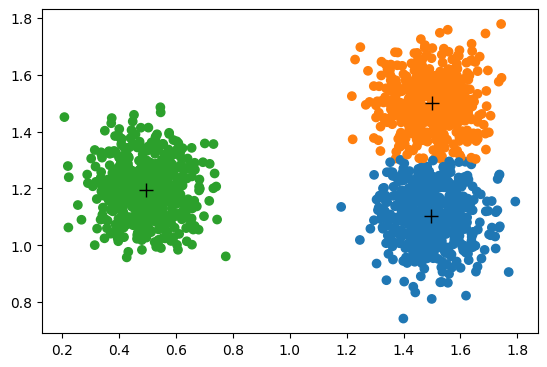

In [14]:
visualization_clusters(X_train, kmeans, classification)

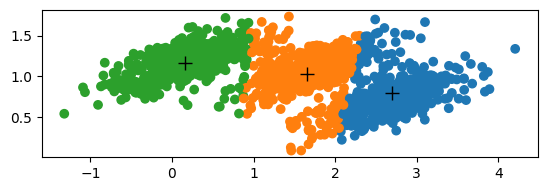

In [15]:
# Try to use k-means++ to cluster the second dataset
X_train_2 = np.load('data/clustering_data2.npy')

# Fit centroids to dataset
kmeans_2 = KMeans(n_clusters=3, max_iter=500, random_seed=110)
kmeans_2.fit(X_train_2)
class_centers_2, classification_2 = kmeans_2.evaluate(X_train_2)
visualization_clusters(X_train_2, kmeans_2, classification_2)

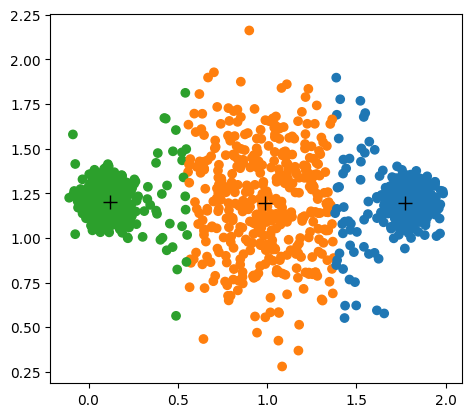

In [16]:
# Try to use k-means++ to cluster the third dataset
X_train_3 = np.load('data/clustering_data3.npy')

# Fit centroids to dataset
kmeans_3 = KMeans(n_clusters=3, max_iter=500, random_seed=110)
kmeans_3.fit(X_train_3)
class_centers_3, classification_3 = kmeans_3.evaluate(X_train_3)
visualization_clusters(X_train_3, kmeans_3, classification_3)

#### <span style="color:red">[TODO]</span> Analyze the limitations of k-means++ (2 pts)
Please notice that there are always three clusters and each of them contains 500 points. What limitations do you observe from the applications of k-means++ on three different datasets? Please also simply discuss why these limitations occur.

In [ ]:
### BEGIN SOLUTION
#(1) The algorithm cannot work quite well for clusters which are non-spherical and the ones which hold different variances.
# For the explanation anything along the lines of (2) or (2') is acceptable.
#(2) From the perspective of each centroid, k-means minimizes the variance within a cluster, which only works well for roughly round clusters. 
# However, for non-spherical clusters, it cannot fully represent the entire non-spherical cluster's structure. 
# As a distance metric, Euclidean distance cannot capture the real data structure either. Especially when some points belonging to a cluster with 
# a larger variance might be closer to other centroids, only relying on Euclidean distance will result in incorrect assignments.
# (2') k-means assigns points to the nearest centroid, as measured by the Euclidean distance. The decision boundary between two centroids is 
# therefore a hyperplane that is equidistant from both centroids, regardless of the shape or size of the clusters. This explains why k-means does
# not perform well with non-spherical clusters and clusters of different variances.
### BEGIN SOLUTION